##**Importing Libraries**

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from pandas_profiling import ProfileReport
from ydata_profiling import ProfileReport
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import pickle

##**Data Preprocessing**

**Loading Data From Kaggle**

In [12]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shriyashjagtap/indian-personal-finance-and-spending-habits",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())
data=Actual_data.copy(deep=True)

/tmp/ipython-input-1714674035.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 8.23M/8.23M [00:00<00:00, 62.0MB/s]


First 5 records:           Income  Age  Dependents     Occupation City_Tier          Rent  \
0   44637.249636   49           0  Self_Employed    Tier_1  13391.174891   
1   26858.596592   34           2        Retired    Tier_2   5371.719318   
2   50367.605084   35           1        Student    Tier_3   7555.140763   
3  101455.600247   21           0  Self_Employed    Tier_3  15218.340037   
4   24875.283548   52           4   Professional    Tier_2   4975.056710   

   Loan_Repayment    Insurance     Groceries    Transport  ...  \
0        0.000000  2206.490129   6658.768341  2636.970696  ...   
1        0.000000   869.522617   2818.444460  1543.018778  ...   
2     4612.103386  2201.800050   6313.222081  3221.396403  ...   
3     6809.441427  4889.418087  14690.149363  7106.130005  ...   
4     3112.609398   635.907170   3034.329665  1276.155163  ...   

   Desired_Savings  Disposable_Income  Potential_Savings_Groceries  \
0      6200.537192       11265.627707                  1685

**Loading Data from locally**

In [ ]:
Actual_data=pd.read_csv("/content/drive/MyDrive/Finance tracker project/data.csv")
data=Actual_data.copy(deep=True)

**Overview of data**

In [ ]:
data.head()
#data.sample()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


**Separating Numerical and categorical Columns**

In [ ]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns
print(num_cols,"\n",cat_cols)

Index(['Income', 'Age', 'Dependents', 'Rent', 'Loan_Repayment', 'Insurance',
       'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities',
       'Healthcare', 'Education', 'Miscellaneous',
       'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income',
       'Potential_Savings_Groceries', 'Potential_Savings_Transport',
       'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment',
       'Potential_Savings_Utilities', 'Potential_Savings_Healthcare',
       'Potential_Savings_Education', 'Potential_Savings_Miscellaneous'],
      dtype='object') 
 Index(['Occupation', 'City_Tier'], dtype='object')


In [ ]:
num_cols[0]

'Income'

**How big is our data**

In [ ]:
data.shape

(20000, 27)

**Datatype of Columns**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  object 
 4   City_Tier                        20000 non-null  object 
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities         

**Checking for Null Values**

In [ ]:
data.isnull().sum()

,0
Income,0
Age,0
Dependents,0
Occupation,0
City_Tier,0
Rent,0
Loan_Repayment,0
Insurance,0
Groceries,0
Transport,0


**How data looks Mathematically**

In [ ]:
data.describe()

,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,4.158550e+04,41.031450,1.995950,9115.494629,2049.800292,1455.028761,5205.667493,2704.466685,1461.856982,1448.853658,...,4982.878416,10647.367257,912.197183,473.042650,254.963280,254.031058,436.332808,41.524964,62.417083,144.904987
std,4.001454e+04,13.578725,1.417616,9254.228188,4281.789941,1492.938435,5035.953689,2666.345648,1481.660811,1489.019270,...,7733.468188,11740.637289,1038.884968,537.222853,296.047943,299.973590,503.200658,53.152458,98.842656,169.160951
min,1.301187e+03,18.000000,0.000000,235.365692,0.000000,30.002012,154.078240,81.228584,39.437523,45.421469,...,0.000000,-5400.788673,16.575501,8.268076,3.797926,3.121610,6.200297,0.001238,0.000000,2.091973
25%,1.760488e+04,29.000000,1.000000,3649.422246,0.000000,580.204749,2165.426419,1124.578012,581.011801,581.632906,...,1224.932636,3774.894323,317.811000,161.913751,84.506870,84.562090,148.013618,11.037421,4.926210,47.637307
50%,3.018538e+04,41.000000,2.000000,6402.751824,0.000000,1017.124681,3741.091535,1933.845509,1029.109726,1020.198376,...,2155.356763,7224.890977,607.038735,307.045856,164.927660,164.740232,285.739582,25.202124,33.127987,93.090257
75%,5.176545e+04,53.000000,3.000000,11263.940492,2627.142320,1787.160895,6470.892718,3360.597508,1807.075251,1790.104082,...,6216.309609,13331.950716,1128.681837,588.419602,313.398240,310.927935,538.983703,52.353736,80.946145,178.257981
max,1.079728e+06,64.000000,4.000000,215945.674703,123080.682009,38734.932935,119816.898124,81861.503457,34406.100166,38667.368308,...,245504.485208,377060.218482,34894.644404,12273.258242,5573.036433,6222.200913,8081.799518,1394.531049,3647.244243,4637.951137


**Checking for Duplicate values**

In [ ]:
data.duplicated().sum()

np.int64(0)

**Encoding**

In [ ]:
for col in ['Occupation','City_Tier']:
  le=LabelEncoder()
  data[col+'encoded']=le.fit_transform(data[col])

In [ ]:
data.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,Occupationencoded,City_Tierencoded
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517,2,0
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606,1,1
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422,3,2
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183,2,2
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076,0,1


**Checking correlation**

##**EDA**

In [ ]:
data.columns

Index(['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent',
       'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out',
       'Entertainment', 'Utilities', 'Healthcare', 'Education',
       'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings',
       'Disposable_Income', 'Potential_Savings_Groceries',
       'Potential_Savings_Transport', 'Potential_Savings_Eating_Out',
       'Potential_Savings_Entertainment', 'Potential_Savings_Utilities',
       'Potential_Savings_Healthcare', 'Potential_Savings_Education',
       'Potential_Savings_Miscellaneous', 'Occupationencoded',
       'City_Tierencoded'],
      dtype='object')

**How many categories of occupation and city_tier**

<Axes: xlabel='count', ylabel='Occupation'>

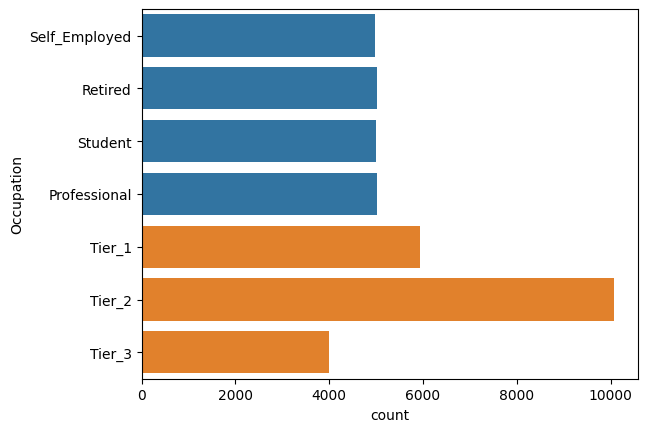

In [ ]:
sns.countplot(data['Occupation'])
sns.countplot(data['City_Tier'])

**How many values in each category**

In [ ]:
print(data['City_Tier'].value_counts(),data['Occupation'].value_counts())

City_Tier
Tier_2    10068
Tier_1     5934
Tier_3     3998
Name: count, dtype: int64 Occupation
Retired          5019
Professional     5011
Student          5003
Self_Employed    4967
Name: count, dtype: int64


(array([420., 438., 414., 460., 440., 430., 428., 424., 405., 428., 421.,
        404.,   0., 408., 406., 389., 414., 449., 424., 390., 437., 424.,
        436., 444.,   0., 430., 403., 448., 448., 435., 461., 481., 400.,
        413., 387., 424., 404.,   0., 431., 380., 443., 441., 439., 440.,
        441., 413., 440., 419., 419., 427.]),
 array([18.  , 18.92, 19.84, 20.76, 21.68, 22.6 , 23.52, 24.44, 25.36,
        26.28, 27.2 , 28.12, 29.04, 29.96, 30.88, 31.8 , 32.72, 33.64,
        34.56, 35.48, 36.4 , 37.32, 38.24, 39.16, 40.08, 41.  , 41.92,
        42.84, 43.76, 44.68, 45.6 , 46.52, 47.44, 48.36, 49.28, 50.2 ,
        51.12, 52.04, 52.96, 53.88, 54.8 , 55.72, 56.64, 57.56, 58.48,
        59.4 , 60.32, 61.24, 62.16, 63.08, 64.  ]),
 <BarContainer object of 50 artists>)

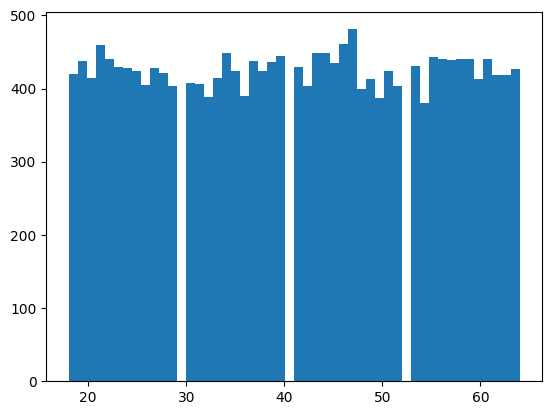

In [ ]:
plt.hist(data['Age'],bins=50)

In [ ]:
data.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,Occupationencoded,City_Tierencoded
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517,2,0
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606,1,1
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422,3,2
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183,2,2
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076,0,1


In [ ]:
# profile = ProfileReport(data, title="EDA Report", explorative=True)
# profile.to_file(output_file='output.html')

**outlier detection and capping**

<Axes: ylabel='Age'>

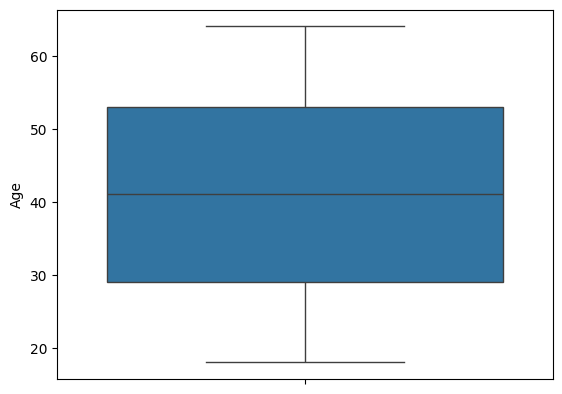

In [ ]:
# sns.boxplot(data[num_cols[0]])
sns.boxplot(data[num_cols[1]])

In [ ]:
outliers={}
for col in num_cols:
  Q1=data[col].quantile(0.25)
  Q3=data[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  mask=(data[col]<lower) | (data[col]>upper)
  outliers[col]=data[mask][col]
print(outliers)

{'Income': 6        106119.692762
31       132028.780019
73       104890.013042
106      135659.233131
113      215248.047335
             ...      
19937    195038.005429
19944    120769.508828
19958    121387.419465
19988    153003.877927
19998    118157.817240
Name: Income, Length: 1254, dtype: float64, 'Age': Series([], Name: Age, dtype: int64), 'Dependents': Series([], Name: Dependents, dtype: int64), 'Rent': 65       26634.745899
73       31467.003913
106      40697.769939
113      64574.414200
125      34609.353222
             ...     
19937    39007.601086
19944    24153.901766
19968    25541.993308
19988    45901.163378
19998    35447.345172
Name: Rent, Length: 1320, dtype: float64, 'Loan_Repayment': 3         6809.441427
7         8307.702220
20        9481.168345
54        9243.340535
64        8786.605014
             ...     
19980     7509.763551
19993    10914.570238
19995     7703.854895
19997     8089.612716
19998    12345.910538
Name: Loan_Repayment, Length: 1880, dt

In [ ]:
for key,value in outliers.items():
  print(key,len(value))

Income 1254
Age 0
Dependents 0
Rent 1320
Loan_Repayment 1880
Insurance 1375
Groceries 1227
Transport 1261
Eating_Out 1325
Entertainment 1324
Utilities 1291
Healthcare 1294
Education 1159
Miscellaneous 1348
Desired_Savings_Percentage 789
Desired_Savings 1303
Disposable_Income 1331
Potential_Savings_Groceries 1401
Potential_Savings_Transport 1395
Potential_Savings_Eating_Out 1431
Potential_Savings_Entertainment 1453
Potential_Savings_Utilities 1383
Potential_Savings_Healthcare 1417
Potential_Savings_Education 1347
Potential_Savings_Miscellaneous 1471


In [ ]:
dataa=pd.read_csv("/content/drive/MyDrive/Finance tracker project/data1.csv")

In [ ]:
num_cols = dataa.select_dtypes(include=['int64','float64']).columns

In [ ]:
for col in num_cols:
  q1, q99 = dataa[col].quantile([0.01, 0.99])
  dataa[col] = dataa[col].clip(q1, q99)

In [ ]:
outliers={}
for col in num_cols:
  Q1=dataa[col].quantile(0.25)
  Q3=dataa[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  mask=(dataa[col]<lower) | (dataa[col]>upper)
  outliers[col]=dataa[mask][col]
print(outliers)

{'Income': 6        106119.692762
31       132028.780019
73       104890.013042
106      135659.233131
113      195484.883088
             ...      
19937    195038.005429
19944    120769.508828
19958    121387.419465
19988    153003.877927
19998    118157.817240
Name: Income, Length: 1254, dtype: float64, 'Age': Series([], Name: Age, dtype: int64), 'Dependents': Series([], Name: Dependents, dtype: int64), 'Rent': 65       26634.745899
73       31467.003913
106      40697.769939
113      44053.544563
125      34609.353222
             ...     
19937    39007.601086
19944    24153.901766
19968    25541.993308
19988    44053.544563
19998    35447.345172
Name: Rent, Length: 1320, dtype: float64, 'Loan_Repayment': 3         6809.441427
7         8307.702220
20        9481.168345
54        9243.340535
64        8786.605014
             ...     
19980     7509.763551
19993    10914.570238
19995     7703.854895
19997     8089.612716
19998    12345.910538
Name: Loan_Repayment, Length: 1880, dt

In [ ]:
for key,value in outliers.items():
  print(key,len(value))

Income 1254
Age 0
Dependents 0
Rent 1320
Loan_Repayment 1880
Insurance 1375
Groceries 1227
Transport 1261
Eating_Out 1325
Entertainment 1324
Utilities 1291
Healthcare 1294
Education 1159
Miscellaneous 1348
Desired_Savings_Percentage 789
Desired_Savings 1303
Disposable_Income 1331
Potential_Savings_Groceries 1401
Potential_Savings_Transport 1395
Potential_Savings_Eating_Out 1431
Potential_Savings_Entertainment 1453
Potential_Savings_Utilities 1383
Potential_Savings_Healthcare 1417
Potential_Savings_Education 1347
Potential_Savings_Miscellaneous 1471
Occupationencoded 0
City_Tierencoded 0


<Axes: ylabel='Potential_Savings_Entertainment'>

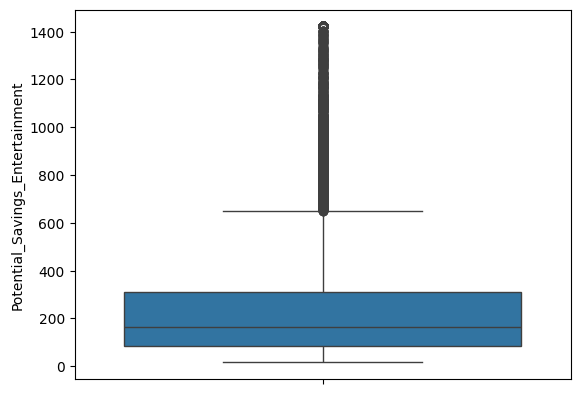

In [ ]:
sns.boxplot(dataa[num_cols[20]])

In [ ]:
# data.to_csv("/content/drive/MyDrive/Finance tracker project/data1.csv",index=False)

##**Feature Engineering**

In [ ]:
data1=pd.read_csv('/content/drive/MyDrive/Finance tracker project/data1.csv')

**1. Total Expenses & Actual Savings**

In [ ]:
expense_cols = [
    'Rent','Loan_Repayment','Insurance','Groceries','Transport',
    'Eating_Out','Entertainment','Utilities','Healthcare',
    'Education','Miscellaneous'
]

data1['Total_Expenses'] = data1[expense_cols].sum(axis=1)
data1['Actual_Savings'] = data1['Income'] - data1['Total_Expenses']
data1.head()


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,Occupationencoded,City_Tierencoded,Total_Expenses,Actual_Savings
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517,2,0,33371.621929,11265.627707
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606,1,1,17181.777859,9676.818733
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422,3,2,36476.154459,13891.450624
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183,2,2,69837.646632,31617.953615
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076,0,1,18609.583016,6265.700532


**2. Overspending Label (Classification Target)**

In [ ]:
data1['Overspend'] = (data1['Actual_Savings'] < 0).astype(int)
data1.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,Occupationencoded,City_Tierencoded,Total_Expenses,Actual_Savings,Overspend
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,195.151320,678.292859,67.682471,0.000000,85.735517,2,0,33371.621929,11265.627707,0
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,234.131168,286.668408,6.603212,56.306874,97.388606,1,1,17181.777859,9676.818733,0
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,459.965256,488.383423,7.290892,106.653597,138.542422,3,2,36476.154459,13891.450624,0
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,320.190594,1389.815033,193.502754,0.000000,296.041183,2,2,69837.646632,31617.953615,0
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,187.173750,194.117130,47.294591,67.388120,96.557076,0,1,18609.583016,6265.700532,0


**3. Weekly Expense Breakdown (4 Weeks)**

In [ ]:
weights = {'W1':0.27, 'W2':0.25, 'W3':0.25, 'W4':0.23}

for col in expense_cols:
    for w, v in weights.items():
        data1[f'{col}_{w}'] = data1[col] * v

for w in weights:
    data1[f'Week_{w}_Total'] = data1[[f'{c}_{w}' for c in expense_cols]].sum(axis=1)
data1.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Education_W3,Education_W4,Miscellaneous_W1,Miscellaneous_W2,Miscellaneous_W3,Miscellaneous_W4,Week_W1_Total,Week_W2_Total,Week_W3_Total,Week_W4_Total
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,0.000000,0.000000,224.511782,207.881280,207.881280,191.250778,9010.337921,8342.905482,8342.905482,7675.473044
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,387.930792,356.896328,152.343452,141.058752,141.058752,129.774052,4639.080022,4295.444465,4295.444465,3951.808908
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,790.006575,726.806049,169.660229,157.092805,157.092805,144.525381,9848.561704,9119.038615,9119.038615,8389.515526
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,0.000000,0.000000,682.035042,631.513928,631.513928,580.992814,18856.164591,17459.411658,17459.411658,16062.658725
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,361.303923,332.399610,139.187781,128.877575,128.877575,118.567369,5024.587414,4652.395754,4652.395754,4280.204094


**4. Spending Trend (Behavior Feature)**

Positive → increasing spending

Negative → improving discipline

In [ ]:
data1['Spending_Trend'] = data1['Week_W4_Total'] - data1['Week_W1_Total']
data1.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Education_W4,Miscellaneous_W1,Miscellaneous_W2,Miscellaneous_W3,Miscellaneous_W4,Week_W1_Total,Week_W2_Total,Week_W3_Total,Week_W4_Total,Spending_Trend
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,0.000000,224.511782,207.881280,207.881280,191.250778,9010.337921,8342.905482,8342.905482,7675.473044,-1334.864877
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,356.896328,152.343452,141.058752,141.058752,129.774052,4639.080022,4295.444465,4295.444465,3951.808908,-687.271114
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,726.806049,169.660229,157.092805,157.092805,144.525381,9848.561704,9119.038615,9119.038615,8389.515526,-1459.046178
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,0.000000,682.035042,631.513928,631.513928,580.992814,18856.164591,17459.411658,17459.411658,16062.658725,-2793.505865
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,332.399610,139.187781,128.877575,128.877575,118.567369,5024.587414,4652.395754,4652.395754,4280.204094,-744.383321


**5. Financial Health Label (Multi-class)**

In [ ]:
def health(row):
    ratio = row['Actual_Savings'] / row['Income']
    if ratio >= 0.20:
        return 'Good'
    elif ratio >= 0.10:
        return 'Average'
    else:
        return 'Poor'

data1['Financial_Health'] = data1.apply(health, axis=1)
data1.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Miscellaneous_W1,Miscellaneous_W2,Miscellaneous_W3,Miscellaneous_W4,Week_W1_Total,Week_W2_Total,Week_W3_Total,Week_W4_Total,Spending_Trend,Financial_Health
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,224.511782,207.881280,207.881280,191.250778,9010.337921,8342.905482,8342.905482,7675.473044,-1334.864877,Good
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,152.343452,141.058752,141.058752,129.774052,4639.080022,4295.444465,4295.444465,3951.808908,-687.271114,Good
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,169.660229,157.092805,157.092805,144.525381,9848.561704,9119.038615,9119.038615,8389.515526,-1459.046178,Good
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,682.035042,631.513928,631.513928,580.992814,18856.164591,17459.411658,17459.411658,16062.658725,-2793.505865,Good
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,139.187781,128.877575,128.877575,118.567369,5024.587414,4652.395754,4652.395754,4280.204094,-744.383321,Good


**6. Top Spending Category (Recommendation Target)**

In [ ]:
data1['Top_Spending_Category'] = data1[expense_cols].idxmax(axis=1)
data1.sample(10)

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Miscellaneous_W2,Miscellaneous_W3,Miscellaneous_W4,Week_W1_Total,Week_W2_Total,Week_W3_Total,Week_W4_Total,Spending_Trend,Financial_Health,Top_Spending_Category
2320,42640.238201,25,4,Retired,Tier_2,8528.047640,0.000000,1148.276450,6322.868820,2333.404023,...,190.464492,190.464492,175.227333,8129.681494,7527.482864,7527.482864,6925.284235,-1204.397258,Good,Rent
9462,27777.534210,24,2,Retired,Tier_2,5555.506842,0.000000,859.153683,2847.344842,1616.669805,...,181.665873,181.665873,167.132603,4873.428297,4512.433608,4512.433608,4151.438920,-721.989377,Good,Rent
2614,48435.494061,54,1,Self_Employed,Tier_2,9687.098812,4241.844483,2170.935758,5940.949016,2465.029571,...,234.363278,234.363278,215.614216,9948.697633,9211.757067,9211.757067,8474.816502,-1473.881131,Good,Rent
6850,12241.882283,21,4,Professional,Tier_3,1836.282342,0.000000,307.452992,1789.784164,910.031899,...,32.214438,32.214438,29.637283,2149.217015,1990.015755,1990.015755,1830.814494,-318.402521,Good,Rent
8390,41179.014032,31,4,Retired,Tier_3,6176.852105,0.000000,889.770396,5758.577994,2158.308155,...,277.861692,277.861692,255.632757,7364.417017,6818.904645,6818.904645,6273.392274,-1091.024743,Good,Rent
16723,73668.321687,47,4,Professional,Tier_2,14733.664337,0.000000,3669.687191,10615.079999,5270.331976,...,273.313657,273.313657,251.448564,14491.078073,13417.664882,13417.664882,12344.251691,-2146.826381,Good,Rent
139,11206.634046,27,3,Retired,Tier_2,2241.326809,935.295269,351.333337,1297.722738,812.261101,...,72.133864,72.133864,66.363155,2310.176232,2139.052067,2139.052067,1967.927901,-342.248331,Good,Rent
15706,12063.339162,52,2,Professional,Tier_1,3619.001749,1825.421895,595.417792,1663.826591,939.529357,...,51.393609,51.393609,47.282120,3102.958495,2873.109718,2873.109718,2643.260940,-459.697555,Poor,Rent
11680,13581.032086,45,0,Student,Tier_2,2716.206417,779.735018,340.657565,1835.593824,786.373375,...,92.007419,92.007419,84.646825,2533.550043,2345.879669,2345.879669,2158.209296,-375.340747,Good,Rent
8198,175277.873916,43,0,Professional,Tier_3,26291.681087,21910.285084,7451.614161,18819.193049,12922.824319,...,1078.195736,1078.195736,991.940077,33071.126143,30621.413095,30621.413095,28171.700048,-4899.426095,Good,Rent


In [ ]:
data1['Top_Spending_Category'].nunique()

2

**7. Savings Gap & Efficiency Features**

In [ ]:
data1['Savings_Gap'] = data1['Desired_Savings'] - data1['Actual_Savings']
data1['Savings_Efficiency'] = data1['Actual_Savings'] / (data1['Desired_Savings'] + 1)
data1.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Miscellaneous_W4,Week_W1_Total,Week_W2_Total,Week_W3_Total,Week_W4_Total,Spending_Trend,Financial_Health,Top_Spending_Category,Savings_Gap,Savings_Efficiency
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,191.250778,9010.337921,8342.905482,8342.905482,7675.473044,-1334.864877,Good,Rent,-5065.090514,1.816586
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,129.774052,4639.080022,4295.444465,4295.444465,3951.808908,-687.271114,Good,Rent,-7753.642299,5.029070
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,144.525381,9848.561704,9119.038615,9119.038615,8389.515526,-1459.046178,Good,Rent,-6841.090203,1.970038
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,580.992814,18856.164591,17459.411658,17459.411658,16062.658725,-2793.505865,Good,Rent,-14922.988478,1.893748
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,118.567369,5024.587414,4652.395754,4652.395754,4280.204094,-744.383321,Good,Rent,-4391.601098,3.341530


In [ ]:
data1.columns

Index(['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent',
       'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out',
       'Entertainment', 'Utilities', 'Healthcare', 'Education',
       'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings',
       'Disposable_Income', 'Potential_Savings_Groceries',
       'Potential_Savings_Transport', 'Potential_Savings_Eating_Out',
       'Potential_Savings_Entertainment', 'Potential_Savings_Utilities',
       'Potential_Savings_Healthcare', 'Potential_Savings_Education',
       'Potential_Savings_Miscellaneous', 'Occupationencoded',
       'City_Tierencoded', 'Total_Expenses', 'Actual_Savings', 'Overspend',
       'Rent_W1', 'Rent_W2', 'Rent_W3', 'Rent_W4', 'Loan_Repayment_W1',
       'Loan_Repayment_W2', 'Loan_Repayment_W3', 'Loan_Repayment_W4',
       'Insurance_W1', 'Insurance_W2', 'Insurance_W3', 'Insurance_W4',
       'Groceries_W1', 'Groceries_W2', 'Groceries_W3', 'Groceries_W4',
       'Transport

In [ ]:
data2=pd.read_csv('/content/drive/MyDrive/Finance tracker project/data.csv')
data2.columns

Index(['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent',
       'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out',
       'Entertainment', 'Utilities', 'Healthcare', 'Education',
       'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings',
       'Disposable_Income', 'Potential_Savings_Groceries',
       'Potential_Savings_Transport', 'Potential_Savings_Eating_Out',
       'Potential_Savings_Entertainment', 'Potential_Savings_Utilities',
       'Potential_Savings_Healthcare', 'Potential_Savings_Education',
       'Potential_Savings_Miscellaneous'],
      dtype='object')

**3. Weekly Financial Pressure Score**

If > 1 → overspending

If 0.6–1 → risky

If < 0.5 → safe



In [ ]:
# Weekly income estimate
data1['Weekly_Income'] = data1['Income'] / 4

# 1. Weekly Savings & Overspend Flags
for w in ['W1', 'W2', 'W3', 'W4']:
    data1[f'Weekly_Savings_{w}'] = data1['Weekly_Income'] - data1[f'Week_{w}_Total']
    data1[f'Weekly_Overspend_{w}'] = (data1[f'Weekly_Savings_{w}'] < 0).astype(int)

# 2. Weekly Financial Pressure (load ratio)
for w in ['W1', 'W2', 'W3', 'W4']:
    data1[f'Weekly_Pressure_{w}'] = (data1[f'Week_{w}_Total'] / (data1['Weekly_Income'] + 1))

# 3. Overspend Trend (behavior signal)
data1['Weekly_Overspend_Trend'] = (data1['Weekly_Overspend_W4'] - data1['Weekly_Overspend_W1'])

# 4. Worst Week (highest spending week)
data1['Worst_Week'] = data1[['Week_W1_Total', 'Week_W2_Total', 'Week_W3_Total', 'Week_W4_Total']].idxmax(axis=1)



In [ ]:
data1.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Weekly_Savings_W3,Weekly_Overspend_W3,Weekly_Savings_W4,Weekly_Overspend_W4,Weekly_Pressure_W1,Weekly_Pressure_W2,Weekly_Pressure_W3,Weekly_Pressure_W4,Weekly_Overspend_Trend,Worst_Week
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,2816.406927,0,3483.839365,0,0.807355,0.747551,0.747551,0.687747,0,Week_W1_Total
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,2419.204683,0,2762.840240,0,0.690787,0.639617,0.639617,0.588448,0,Week_W1_Total
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,3472.862656,0,4202.385745,0,0.782072,0.724141,0.724141,0.666210,0,Week_W1_Total
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,7904.488404,0,9301.241336,0,0.743396,0.688330,0.688330,0.633263,0,Week_W1_Total
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1566.425133,0,1938.616793,0,0.807835,0.747995,0.747995,0.688156,0,Week_W1_Total


In [ ]:
data1.columns

Index(['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent',
       'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out',
       'Entertainment', 'Utilities', 'Healthcare', 'Education',
       'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings',
       'Disposable_Income', 'Potential_Savings_Groceries',
       'Potential_Savings_Transport', 'Potential_Savings_Eating_Out',
       'Potential_Savings_Entertainment', 'Potential_Savings_Utilities',
       'Potential_Savings_Healthcare', 'Potential_Savings_Education',
       'Potential_Savings_Miscellaneous', 'Occupationencoded',
       'City_Tierencoded', 'Total_Expenses', 'Actual_Savings', 'Overspend',
       'Rent_W1', 'Rent_W2', 'Rent_W3', 'Rent_W4', 'Loan_Repayment_W1',
       'Loan_Repayment_W2', 'Loan_Repayment_W3', 'Loan_Repayment_W4',
       'Insurance_W1', 'Insurance_W2', 'Insurance_W3', 'Insurance_W4',
       'Groceries_W1', 'Groceries_W2', 'Groceries_W3', 'Groceries_W4',
       'Transport

In [ ]:
# data1.to_csv('/content/drive/MyDrive/Finance tracker project/data2.csv')

## **Pandas Profiling**

a tool that does all the EDA(Exploratory Data Analysis) automatically.

**Generating EDA report using Pandas Profiling**

In [ ]:
initial_data=pd.read_csv('/content/drive/MyDrive/Finance tracker project/data.csv')

In [ ]:
# profile = ProfileReport(initial_data, title="EDA Report", explorative=True)
# profile.to_file(output_file='/content/drive/MyDrive/Finance tracker project/EDA/EDA_initial_data.html')

In [ ]:
profile1=ProfileReport(initial_data)

In [11]:
# profile1.to_notebook_iframe()

## **Training The Models**

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Finance tracker project/data2.csv')

In [ ]:
j=-1
for i in df.columns:
  j+=1
  if j==5:
    print('\n')
    j=0
  print(i,end=' = ')

Unnamed: 0 = Income = Age = Dependents = Occupation = 

City_Tier = Rent = Loan_Repayment = Insurance = Groceries = 

Transport = Eating_Out = Entertainment = Utilities = Healthcare = 

Education = Miscellaneous = Desired_Savings_Percentage = Desired_Savings = Disposable_Income = 

Potential_Savings_Groceries = Potential_Savings_Transport = Potential_Savings_Eating_Out = Potential_Savings_Entertainment = Potential_Savings_Utilities = 

Potential_Savings_Healthcare = Potential_Savings_Education = Potential_Savings_Miscellaneous = Occupationencoded = City_Tierencoded = 

Total_Expenses = Actual_Savings = Overspend = Rent_W1 = Rent_W2 = 

Rent_W3 = Rent_W4 = Loan_Repayment_W1 = Loan_Repayment_W2 = Loan_Repayment_W3 = 

Loan_Repayment_W4 = Insurance_W1 = Insurance_W2 = Insurance_W3 = Insurance_W4 = 

Groceries_W1 = Groceries_W2 = Groceries_W3 = Groceries_W4 = Transport_W1 = 

Transport_W2 = Transport_W3 = Transport_W4 = Eating_Out_W1 = Eating_Out_W2 = 

Eating_Out_W3 = Eating_Out_W4 = Ente

In [ ]:
correlation_matrix=df[[    'Income','Age','Dependents','Occupationencoded','City_Tierencoded' ,'Total_Expenses']].corr()
correlation_matrix


,Income,Age,Dependents,Occupationencoded,City_Tierencoded,Total_Expenses
Income,1.000000,-0.005201,0.016926,0.001645,0.008684,0.982985
Age,-0.005201,1.000000,-0.011342,-0.010400,0.002125,-0.005872
Dependents,0.016926,-0.011342,1.000000,0.002250,-0.005449,0.045592
Occupationencoded,0.001645,-0.010400,0.002250,1.000000,-0.000492,0.001883
City_Tierencoded,0.008684,0.002125,-0.005449,-0.000492,1.000000,-0.066801
Total_Expenses,0.982985,-0.005872,0.045592,0.001883,-0.066801,1.000000


In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df['Financial_Health'].value_counts()

,count
Financial_Health,
Good,14252
Average,4371
Poor,1377


##**MODELS 1:**
Predicts: Overspend (0/1 classification)

Data Splitting + Scaling

In [ ]:
# y = df['Overspend']
# feature_cols = [
    # 'Income', 'Age', 'Dependents', 'Occupationencoded', 'City_Tierencoded',
    # 'Rent_W1','Rent_W2','Rent_W3','Rent_W4',
    # 'Loan_Repayment_W1','Loan_Repayment_W2','Loan_Repayment_W3','Loan_Repayment_W4',
    # 'Insurance_W1','Insurance_W2','Insurance_W3','Insurance_W4',
    # 'Groceries_W1','Groceries_W2','Groceries_W3','Groceries_W4',
    # 'Transport_W1','Transport_W2','Transport_W3','Transport_W4',
    # 'Eating_Out_W1','Eating_Out_W2','Eating_Out_W3','Eating_Out_W4',
    # 'Entertainment_W1','Entertainment_W2','Entertainment_W3','Entertainment_W4',
    # 'Utilities_W1','Utilities_W2','Utilities_W3','Utilities_W4',
    # 'Healthcare_W1','Healthcare_W2','Healthcare_W3','Healthcare_W4',
    # 'Education_W1','Education_W2','Education_W3','Education_W4',
    # 'Miscellaneous_W1','Miscellaneous_W2','Miscellaneous_W3','Miscellaneous_W4',
    # 'Total_Expenses','Disposable_Income'
# ]


# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

# X = df[feature_cols]
# y = df['Overspend']

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Scale features for Perceptron
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


Training models

In [ ]:
# from sklearn.linear_model import Perceptron
# from sklearn.tree import DecisionTreeClassifier

# # Perceptron
# perceptron = Perceptron(max_iter=1000, random_state=42)
# perceptron.fit(X_train_scaled, y_train)

# # Decision Tree
# dtree = DecisionTreeClassifier(random_state=42)
# dtree.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

CROSS-VALIDATION CODE (Perceptron)

In [ ]:
from sklearn.model_selection import cross_val_score

# Perceptron CV
cv_perceptron = cross_val_score(perceptron, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Perceptron CV Accuracy:", cv_perceptron.mean())

# Decision Tree CV
cv_dtree = cross_val_score(dtree, X_train, y_train, cv=5, scoring='accuracy')
print("Decision Tree CV Accuracy:", cv_dtree.mean())


Perceptron CV Accuracy: 0.9938125000000001
Decision Tree CV Accuracy: 0.999875


Evaluation on Test Set

In [ ]:
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# # Predictions
# y_pred_perceptron = perceptron.predict(X_test_scaled)
# y_pred_dtree = dtree.predict(X_test)

# # Accuracy
# print("Perceptron Test Accuracy:", accuracy_score(y_test, y_pred_perceptron))
# print("Decision Tree Test Accuracy:", accuracy_score(y_test, y_pred_dtree))

# # Detailed report
# print("Perceptron Classification Report:\n", classification_report(y_test, y_pred_perceptron))
# print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dtree))


Perceptron Test Accuracy: 0.961
Decision Tree Test Accuracy: 1.0
Perceptron Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98      3978
           1       0.09      0.68      0.16        22

    accuracy                           0.96      4000
   macro avg       0.54      0.82      0.57      4000
weighted avg       0.99      0.96      0.98      4000

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3978
           1       1.00      1.00      1.00        22

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



Confusion Matrix

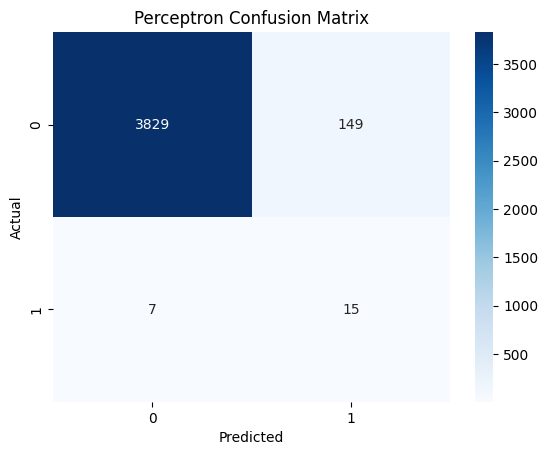

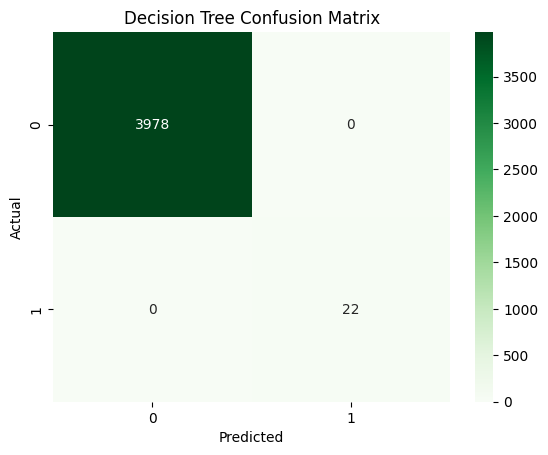

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Perceptron
# cm_perceptron = confusion_matrix(y_test, y_pred_perceptron)
# sns.heatmap(cm_perceptron, annot=True, fmt='d', cmap='Blues')
# plt.title("Perceptron Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # Decision Tree
# cm_dtree = confusion_matrix(y_test, y_pred_dtree)
# sns.heatmap(cm_dtree, annot=True, fmt='d', cmap='Greens')
# plt.title("Decision Tree Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()


Testing on Real-World Data

In [ ]:
# # Example new user data
# new_user = pd.DataFrame([{
#     'Income': 7000, 'Age': 28, 'Dependents': 0, 'Occupationencoded': 3, 'City_Tierencoded': 2,
#     'Rent_W1': 1000,'Rent_W2': 1000,'Rent_W3': 1000,'Rent_W4': 1000,
#     'Loan_Repayment_W1': 500,'Loan_Repayment_W2': 500,'Loan_Repayment_W3': 500,'Loan_Repayment_W4': 500,
#     'Insurance_W1': 200,'Insurance_W2': 200,'Insurance_W3': 200,'Insurance_W4': 200,
#     'Groceries_W1': 300,'Groceries_W2': 320,'Groceries_W3': 280,'Groceries_W4': 310,
#     'Transport_W1': 100,'Transport_W2': 120,'Transport_W3': 90,'Transport_W4': 110,
#     'Eating_Out_W1': 150,'Eating_Out_W2': 170,'Eating_Out_W3': 140,'Eating_Out_W4': 160,
#     'Entertainment_W1': 80,'Entertainment_W2': 70,'Entertainment_W3': 60,'Entertainment_W4': 90,
#     'Utilities_W1': 100,'Utilities_W2': 110,'Utilities_W3': 105,'Utilities_W4': 95,
#     'Healthcare_W1': 50,'Healthcare_W2': 60,'Healthcare_W3': 55,'Healthcare_W4': 50,
#     'Education_W1': 0,'Education_W2': 0,'Education_W3': 0,'Education_W4': 0,
#     'Miscellaneous_W1': 60,'Miscellaneous_W2': 80,'Miscellaneous_W3': 70,'Miscellaneous_W4': 65,
#     'Total_Expenses': 6200, 'Disposable_Income': 800
# }])

# # Scale for Perceptron
# new_user_scaled = scaler.transform(new_user[feature_cols])

# # Predict
# overspend_pred_perceptron = perceptron.predict(new_user_scaled)
# overspend_pred_dtree = dtree.predict(new_user)

# print("Predicted Overspend (Perceptron):", overspend_pred_perceptron[0])
# print("Predicted Overspend (Decision Tree):", overspend_pred_dtree[0])


Predicted Overspend (Perceptron): 0
Predicted Overspend (Decision Tree): 0


Saving the model:

In [ ]:
# import pickle

# # Save Perceptron
# with open("/content/drive/MyDrive/Finance tracker project/perceptron_model.pkl", "wb") as f:
#     pickle.dump(perceptron, f)

# # Save Decision Tree
# with open("/content/drive/MyDrive/Finance tracker project/decision_tree_model.pkl", "wb") as f:
#     pickle.dump(dtree, f)

# # Save the scaler (important for Perceptron)
# with open("/content/drive/MyDrive/Finance tracker project/scaler.pkl", "wb") as f:
#     pickle.dump(scaler, f)

# print("Models and scaler saved successfully!")


Models and scaler saved successfully!


##**Models 2**

How much he will save at the end of the month

Step 1: Feature Selection

Use features that influence savings

In [ ]:
# feature_cols = [
#     'Income', 'Age', 'Dependents', 'Occupationencoded', 'City_Tierencoded',
#     'Rent_W1','Rent_W2','Rent_W3','Rent_W4',
#     'Loan_Repayment_W1','Loan_Repayment_W2','Loan_Repayment_W3','Loan_Repayment_W4',
#     'Insurance_W1','Insurance_W2','Insurance_W3','Insurance_W4',
#     'Groceries_W1','Groceries_W2','Groceries_W3','Groceries_W4',
#     'Transport_W1','Transport_W2','Transport_W3','Transport_W4',
#     'Eating_Out_W1','Eating_Out_W2','Eating_Out_W3','Eating_Out_W4',
#     'Entertainment_W1','Entertainment_W2','Entertainment_W3','Entertainment_W4',
#     'Utilities_W1','Utilities_W2','Utilities_W3','Utilities_W4',
#     'Healthcare_W1','Healthcare_W2','Healthcare_W3','Healthcare_W4',
#     'Education_W1','Education_W2','Education_W3','Education_W4',
#     'Miscellaneous_W1','Miscellaneous_W2','Miscellaneous_W3','Miscellaneous_W4',
#     'Total_Expenses','Disposable_Income','Potential_Savings_Groceries','Potential_Savings_Transport',
#     'Potential_Savings_Eating_Out','Potential_Savings_Entertainment','Potential_Savings_Utilities',
#     'Potential_Savings_Healthcare','Potential_Savings_Education','Potential_Savings_Miscellaneous'
# ]

# X = df[feature_cols]
# y = df['Actual_Savings']


Step 2: Data Preprocessing

Scale features for Linear Regression (optional for trees)

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Scale features for Linear Regression
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


Step 3: Train Models

In [ ]:
# from sklearn.linear_model import LinearRegression
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor

# # Linear Regression
# lin_reg = LinearRegression()
# lin_reg.fit(X_train_scaled, y_train)

# # Decision Tree Regressor
# dt_reg = DecisionTreeRegressor(random_state=42)
# dt_reg.fit(X_train, y_train)

# # Random Forest Regressor
# rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
# rf_reg.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

Step 4: Cross-Validation

In [ ]:
# from sklearn.model_selection import cross_val_score
# import numpy as np

# # Linear Regression CV
# cv_lin = cross_val_score(lin_reg, X_train_scaled, y_train, cv=5, scoring='r2')
# print("Linear Regression CV R2:", np.mean(cv_lin))

# # Decision Tree CV
# cv_dt = cross_val_score(dt_reg, X_train, y_train, cv=5, scoring='r2')
# print("Decision Tree CV R2:", np.mean(cv_dt))

# # Random Forest CV
# cv_rf = cross_val_score(rf_reg, X_train, y_train, cv=5, scoring='r2')
# print("Random Forest CV R2:", np.mean(cv_rf))


Linear Regression CV R2: 1.0
Decision Tree CV R2: 0.9928153455225492
Random Forest CV R2: 0.9924590007340722


Step 5: Evaluation on Test Set

In [ ]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np

# # Predictions
# y_pred_lin = lin_reg.predict(X_test_scaled)
# y_pred_dt = dt_reg.predict(X_test)
# y_pred_rf = rf_reg.predict(X_test)

# # Metrics
# def eval_model(y_true, y_pred, name):
#     print(f"---{name}---")
#     print("R2 Score:", round(r2_score(y_true, y_pred),2))
#     print("MAE:", round(mean_absolute_error(y_true, y_pred),3))
#     print("MSE:", round(mean_squared_error(y_true, y_pred),3))
#     print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)),3))
#     print("\n")


# eval_model(y_test, y_pred_lin, "Linear Regression")
# eval_model(y_test, y_pred_dt, "Decision Tree Regressor")
# eval_model(y_test, y_pred_rf, "Random Forest Regressor")


---Linear Regression---
R2 Score: 1.0
MAE: 0.0
MSE: 0.0
RMSE: 0.0


---Decision Tree Regressor---
R2 Score: 0.92
MAE: 76.515
MSE: 13342336.46
RMSE: 3652.716


---Random Forest Regressor---
R2 Score: 0.95
MAE: 57.31
MSE: 8237239.881
RMSE: 2870.059




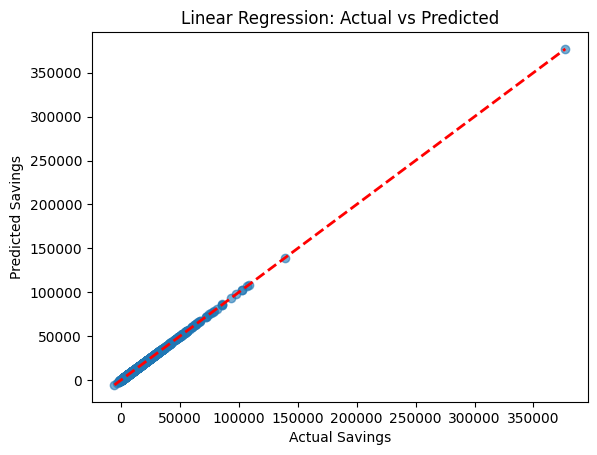

In [ ]:
# import matplotlib.pyplot as plt

# # Linear Regression example
# plt.scatter(y_test, y_pred_lin, alpha=0.6)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # diagonal
# plt.xlabel("Actual Savings")
# plt.ylabel("Predicted Savings")
# plt.title("Linear Regression: Actual vs Predicted")
# plt.show()


Step 6: Feature Importance (for trees)

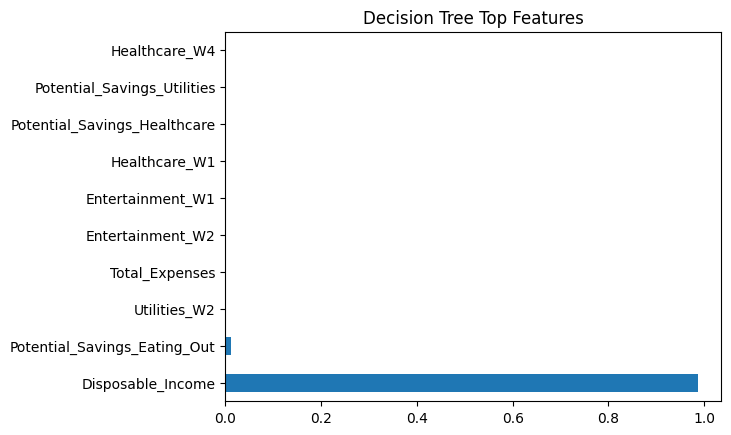

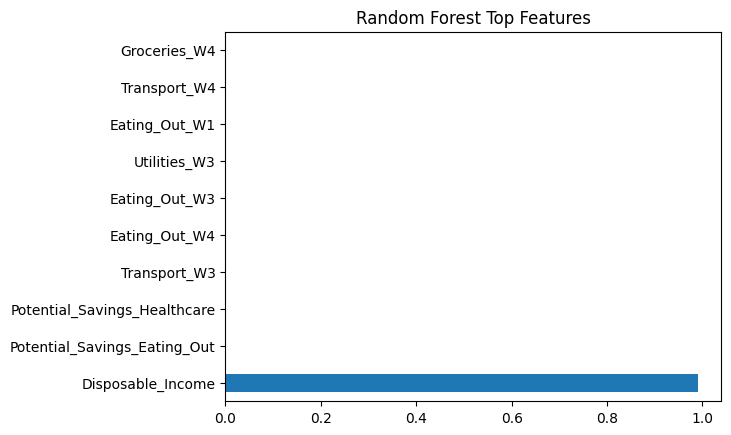

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd

# # Decision Tree
# dt_importances = pd.Series(dt_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
# dt_importances[:10].plot(kind='barh', title='Decision Tree Top Features')
# plt.show()

# # Random Forest
# rf_importances = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
# rf_importances[:10].plot(kind='barh', title='Random Forest Top Features')
# plt.show()


Step 7: Test on Real-World Data

In [ ]:
# new_user = pd.DataFrame([{
#     'Income': 7000, 'Age': 28, 'Dependents': 0, 'Occupationencoded': 3, 'City_Tierencoded': 2,
#     'Rent_W1': 1000,'Rent_W2': 1000,'Rent_W3': 1000,'Rent_W4': 1000,
#     'Loan_Repayment_W1': 500,'Loan_Repayment_W2': 500,'Loan_Repayment_W3': 500,'Loan_Repayment_W4': 500,
#     'Insurance_W1': 200,'Insurance_W2': 200,'Insurance_W3': 200,'Insurance_W4': 200,
#     'Groceries_W1': 300,'Groceries_W2': 320,'Groceries_W3': 280,'Groceries_W4': 310,
#     'Transport_W1': 100,'Transport_W2': 120,'Transport_W3': 90,'Transport_W4': 110,
#     'Eating_Out_W1': 150,'Eating_Out_W2': 170,'Eating_Out_W3': 140,'Eating_Out_W4': 160,
#     'Entertainment_W1': 80,'Entertainment_W2': 70,'Entertainment_W3': 60,'Entertainment_W4': 90,
#     'Utilities_W1': 100,'Utilities_W2': 110,'Utilities_W3': 105,'Utilities_W4': 95,
#     'Healthcare_W1': 50,'Healthcare_W2': 60,'Healthcare_W3': 55,'Healthcare_W4': 50,
#     'Education_W1': 0,'Education_W2': 0,'Education_W3': 0,'Education_W4': 0,
#     'Miscellaneous_W1': 60,'Miscellaneous_W2': 80,'Miscellaneous_W3': 70,'Miscellaneous_W4': 65,
#     'Total_Expenses': 6200, 'Disposable_Income': 800,
#     'Potential_Savings_Groceries': 50,'Potential_Savings_Transport': 30,'Potential_Savings_Eating_Out': 60,
#     'Potential_Savings_Entertainment': 20,'Potential_Savings_Utilities': 15,'Potential_Savings_Healthcare': 10,
#     'Potential_Savings_Education': 0,'Potential_Savings_Miscellaneous': 10
# }])

# # Scale for Linear Regression
# new_user_scaled = scaler.transform(new_user[feature_cols])

# print("Predicted Savings (Linear Regression):", lin_reg.predict(new_user_scaled)[0])
# print("Predicted Savings (Decision Tree):", dt_reg.predict(new_user)[0])
# print("Predicted Savings (Random Forest):", rf_reg.predict(new_user)[0])


Predicted Savings (Linear Regression): 497.61210770197613
Predicted Savings (Decision Tree): 800.4259560893734
Predicted Savings (Random Forest): 799.9701065174214


Step 8: Save Models

In [ ]:
# import pickle

# # Linear Regression
# with open("/content/drive/MyDrive/Finance tracker project/Savings Models/linear_regressor.pkl", "wb") as f:
#     pickle.dump(lin_reg, f)

# # Decision Tree Regressor
# with open("/content/drive/MyDrive/Finance tracker project/Savings Models/decision_tree_regressor.pkl", "wb") as f:
#     pickle.dump(dt_reg, f)

# # Random Forest Regressor
# with open("/content/drive/MyDrive/Finance tracker project/Savings Models/random_forest_regressor.pkl", "wb") as f:
#     pickle.dump(rf_reg, f)

# # Scaler for Linear Regression
# with open("/content/drive/MyDrive/Finance tracker project/Savings Models/scaler_savings.pkl", "wb") as f:
#     pickle.dump(scaler, f)

# print("All models and scaler saved successfully!")


All models and scaler saved successfully!


##**Models 3**

Financial Health (Good, Average, Poor)



Classifying his financial health

Step 1: Feature Selection (Current Month)

In [ ]:
# feature_cols = [
#     'Total_Expenses',
#     'Weekly_Overspend_Trend',
#     'Disposable_Income',
#     'Spending_Trend',
#     'Savings_Efficiency'
# ]

# X = df[feature_cols]
# y = df['Financial_Health']  # current health: Good / Average / Poor


Step 2: Encode Target

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# y_encoded = le.fit_transform(y)  # Good->0, Average->1, Poor->2


Step 3: Train/Test Split

In [ ]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
# )


Step 4: Scale Features (for KNN & Naive Bayes)

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


Step 5: Train Models

In [ ]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB

# # Decision Tree
# dtree = DecisionTreeClassifier(random_state=42)
# dtree.fit(X_train, y_train)  # use unscaled features

# # KNN
# knn = KNeighborsClassifier(n_neighbors=5)
# knn.fit(X_train_scaled, y_train)

# # Naive Bayes
# nb = GaussianNB()
# nb.fit(X_train_scaled, y_train)


GaussianNB()

Step 6: Cross-Validation

In [ ]:
# from sklearn.model_selection import cross_val_score
# import numpy as np

# cv_dt = cross_val_score(dtree, X_train, y_train, cv=5, scoring='accuracy')
# cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
# cv_nb = cross_val_score(nb, X_train_scaled, y_train, cv=5, scoring='accuracy')

# print("Decision Tree CV Accuracy:", np.mean(cv_dt))
# print("KNN CV Accuracy:", np.mean(cv_knn))
# print("Naive Bayes CV Accuracy:", np.mean(cv_nb))


Decision Tree CV Accuracy: 0.9741875
KNN CV Accuracy: 0.9876250000000001
Naive Bayes CV Accuracy: 0.8703749999999999


Step 7: Evaluation on Test Set

In [ ]:
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Predictions
# y_pred_dt = dtree.predict(X_test)
# y_pred_knn = knn.predict(X_test_scaled)
# y_pred_nb = nb.predict(X_test_scaled)

# # Accuracy
# print("Decision Tree Test Accuracy:", accuracy_score(y_test, y_pred_dt))
# print("KNN Test Accuracy:", accuracy_score(y_test, y_pred_knn))
# print("Naive Bayes Test Accuracy:", accuracy_score(y_test, y_pred_nb))

# # Classification Reports
# print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt, target_names=le.classes_))
# print("KNN Report:\n", classification_report(y_test, y_pred_knn, target_names=le.classes_))
# print("Naive Bayes Report:\n", classification_report(y_test, y_pred_nb, target_names=le.classes_))


Decision Tree Test Accuracy: 0.96625
KNN Test Accuracy: 0.98925
Naive Bayes Test Accuracy: 0.85925
Decision Tree Report:
               precision    recall  f1-score   support

     Average       0.92      0.93      0.92       874
        Good       0.98      0.98      0.98      2850
        Poor       0.94      0.92      0.93       276

    accuracy                           0.97      4000
   macro avg       0.95      0.94      0.95      4000
weighted avg       0.97      0.97      0.97      4000

KNN Report:
               precision    recall  f1-score   support

     Average       0.97      0.98      0.98       874
        Good       1.00      0.99      0.99      2850
        Poor       0.99      0.96      0.97       276

    accuracy                           0.99      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.99      0.99      0.99      4000

Naive Bayes Report:
               precision    recall  f1-score   support

     Average       0.66    

Step 8: Confusion Matrix

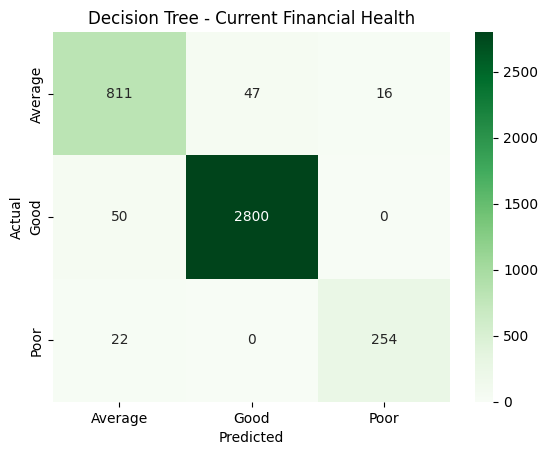

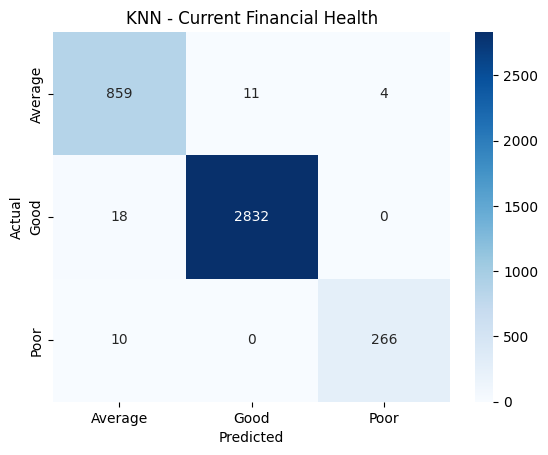

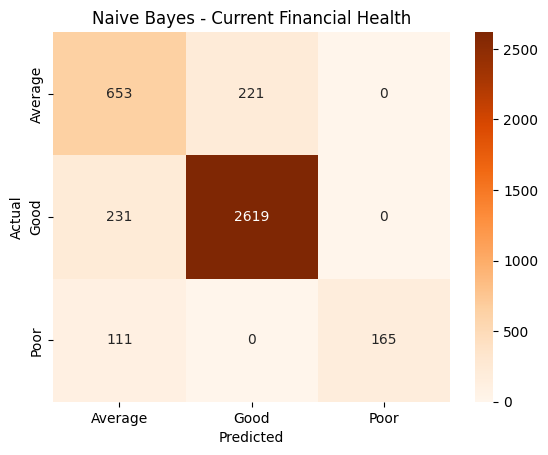

In [ ]:
# # Decision Tree
# cm_dt = confusion_matrix(y_test, y_pred_dt)
# sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
# plt.title("Decision Tree - Current Financial Health")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # KNN
# cm_knn = confusion_matrix(y_test, y_pred_knn)
# sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
# plt.title("KNN - Current Financial Health")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # Naive Bayes
# cm_nb = confusion_matrix(y_test, y_pred_nb)
# sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
# plt.title("Naive Bayes - Current Financial Health")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()


Step 9: Real-World Prediction

In [ ]:
# new_user = pd.DataFrame([{
#     'Total_Expenses': 6200,
#     'Weekly_Overspend_Trend': 1,
#     'Disposable_Income': 800,
#     'Spending_Trend': 1,
#     'Savings_Efficiency': 0.72
# }])

# # Scale for KNN and Naive Bayes
# new_user_scaled = scaler.transform(new_user)

# pred_dt = le.inverse_transform(dtree.predict(new_user))
# pred_knn = le.inverse_transform(knn.predict(new_user_scaled))
# pred_nb = le.inverse_transform(nb.predict(new_user_scaled))

# print("Predicted Current Financial Health (Decision Tree):", pred_dt[0])
# print("Predicted Current Financial Health (KNN):", pred_knn[0])
# print("Predicted Current Financial Health (Naive Bayes):", pred_nb[0])


Predicted Current Financial Health (Decision Tree): Poor
Predicted Current Financial Health (KNN): Average
Predicted Current Financial Health (Naive Bayes): Poor


Step 10: Predict Probabilities

In [ ]:
# # Probability predictions
# proba_dt = dtree.predict_proba(new_user)[0]
# proba_knn = knn.predict_proba(new_user_scaled)[0]
# proba_nb = nb.predict_proba(new_user_scaled)[0]

# print("Models        Probability of","[Average, Good, Poor]")
# print("Decision Tree probabilities:", proba_dt)
# print("KNN probabilities:", proba_knn)
# print("Naive Bayes probabilities:", proba_nb)


Models        Probability of [Average, Good, Poor]
Decision Tree probabilities: [0. 0. 1.]
KNN probabilities: [0.6 0.4 0. ]
Naive Bayes probabilities: [0. 0. 1.]


Combined Comparison Chart

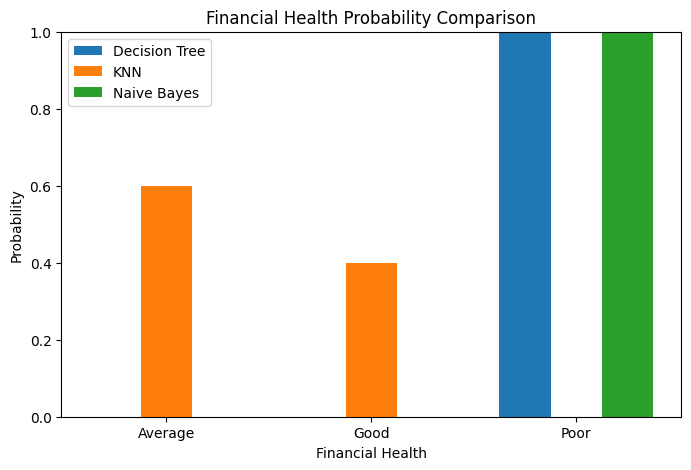

In [ ]:
# import numpy as np

# plt.figure(figsize=(8,5))
# classes = le.classes_

# x = np.arange(len(classes))
# width = 0.25

# plt.bar(x - width, proba_dt, width, label='Decision Tree')
# plt.bar(x,         proba_knn, width, label='KNN')
# plt.bar(x + width, proba_nb, width, label='Naive Bayes')

# plt.xticks(x, classes)
# plt.xlabel("Financial Health")
# plt.ylabel("Probability")
# plt.title("Financial Health Probability Comparison")
# plt.legend()
# plt.ylim(0,1)
# plt.show()


Step 10: Save Models

In [ ]:
# import pickle

# with open("/content/drive/MyDrive/Finance tracker project/Financial Health/financial_health_dt.pkl", "wb") as f:
#     pickle.dump(dtree, f)

# with open("/content/drive/MyDrive/Finance tracker project/Financial Health/financial_health_knn.pkl", "wb") as f:
#     pickle.dump(knn, f)

# with open("/content/drive/MyDrive/Finance tracker project/Financial Health/financial_health_nb.pkl", "wb") as f:
#     pickle.dump(nb, f)

# with open("/content/drive/MyDrive/Finance tracker project/Financial Health/financial_health_scaler.pkl", "wb") as f:
#     pickle.dump(scaler, f)

# with open("/content/drive/MyDrive/Finance tracker project/Financial Health/financial_health_labelencoder.pkl", "wb") as f:
#     pickle.dump(le, f)

# print("All Financial Health models saved successfully!")


All Financial Health models saved successfully!


##**Models 4**

sugesting savings in expense categories

STEP 1 — Define ALL Target Columns (8 savings columns)

In [ ]:
targets = [
    "Potential_Savings_Groceries",
    "Potential_Savings_Transport",
    "Potential_Savings_Eating_Out",
    "Potential_Savings_Entertainment",
    "Potential_Savings_Utilities",
    "Potential_Savings_Healthcare",
    "Potential_Savings_Education",
    "Potential_Savings_Miscellaneous"
]

y = df[targets]


STEP 2 — Select Features (only from your dataset)

✔ Financial profile
✔ Weekly spending
✔ Behavior metrics

In [ ]:
# Base financial features
features = [
    "Income","Age","Dependents","Occupationencoded","City_Tierencoded",
    "Disposable_Income","Desired_Savings","Savings_Efficiency",
    "Spending_Trend","Weekly_Income","Weekly_Overspend_Trend",
    "Total_Expenses","Actual_Savings"
]

# Add all weekly columns (_W) automatically
weekly_cols = [col for col in df.columns if "_W" in col]
features.extend(weekly_cols)

# Remove non-numeric columns (like Worst_Week)
features = [f for f in features if f != "Worst_Week"]


STEP 5 — Convert All Features to Numeric and Handle Errors

In [ ]:
# Convert all features to numeric (force numbers, convert invalid entries to NaN)
for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill NaN with 0 (or use median if preferred)
df[features] = df[features].fillna(0)


STEP 6 — Prepare Feature & Target Data

In [ ]:
# Features
X = df[features]

# Targets (y) — the 8 potential savings columns
targets = [
    "Potential_Savings_Groceries",
    "Potential_Savings_Transport",
    "Potential_Savings_Eating_Out",
    "Potential_Savings_Entertainment",
    "Potential_Savings_Utilities",
    "Potential_Savings_Healthcare",
    "Potential_Savings_Education",
    "Potential_Savings_Miscellaneous"
]

y = df[targets]


STEP 3 — Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


STEP 4 — Define 3 Multi-Output Models

In [ ]:
lr = MultiOutputRegressor(LinearRegression())
dt = MultiOutputRegressor(DecisionTreeRegressor(max_depth=8, random_state=42))
knn = MultiOutputRegressor(KNeighborsRegressor(n_neighbors=5))

models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "KNN Regressor": knn
}


STEP 7 — Train All Models

In [ ]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)


Training Linear Regression...
Training Decision Tree...
Training KNN Regressor...


STEP 10 — Define Evaluation Function

In [ ]:
def evaluate(model, name):
    preds = model.predict(X_test)
    print("\n-----", name, "-----")

    for i, col in enumerate(targets):
        mae = mean_absolute_error(y_test[col], preds[:, i])
        rmse = np.sqrt(mean_squared_error(y_test[col], preds[:, i]))
        r2 = r2_score(y_test[col], preds[:, i])

        print(f"\nTarget: {col}")
        print("MAE:", mae)
        print("RMSE:", rmse)
        print("R2 Score:", r2)

    return preds


STEP 11 — Evaluate All Models

In [ ]:
lr_preds = evaluate(lr, "Linear Regression")
dt_preds = evaluate(dt, "Decision Tree Regressor")
knn_preds = evaluate(knn, "KNN Regressor")



----- Linear Regression -----

Target: Potential_Savings_Groceries
MAE: 325.08160287508883
RMSE: 570.0713709534106
R2 Score: 0.7350693765525158

Target: Potential_Savings_Transport
MAE: 174.94720262795087
RMSE: 320.37694231785576
R2 Score: 0.6609945103291139

Target: Potential_Savings_Eating_Out
MAE: 90.03088233737832
RMSE: 149.95190745227038
R2 Score: 0.7655973276778543

Target: Potential_Savings_Entertainment
MAE: 88.48705035072072
RMSE: 154.76825288604297
R2 Score: 0.7199970370952753

Target: Potential_Savings_Utilities
MAE: 153.70486340481008
RMSE: 251.09214527097365
R2 Score: 0.7692987536099732

Target: Potential_Savings_Healthcare
MAE: 20.701915964137537
RMSE: 34.268068972738135
R2 Score: 0.6310543314125154

Target: Potential_Savings_Education
MAE: 31.72178634239987
RMSE: 65.22610717419337
R2 Score: 0.670181832723698

Target: Potential_Savings_Miscellaneous
MAE: 51.45167434706027
RMSE: 89.9582997647972
R2 Score: 0.7588138208927167

----- Decision Tree Regressor -----

Target: Po

STEP 12 — Multi-Output Regression Error Plot (Linear Regression Example)

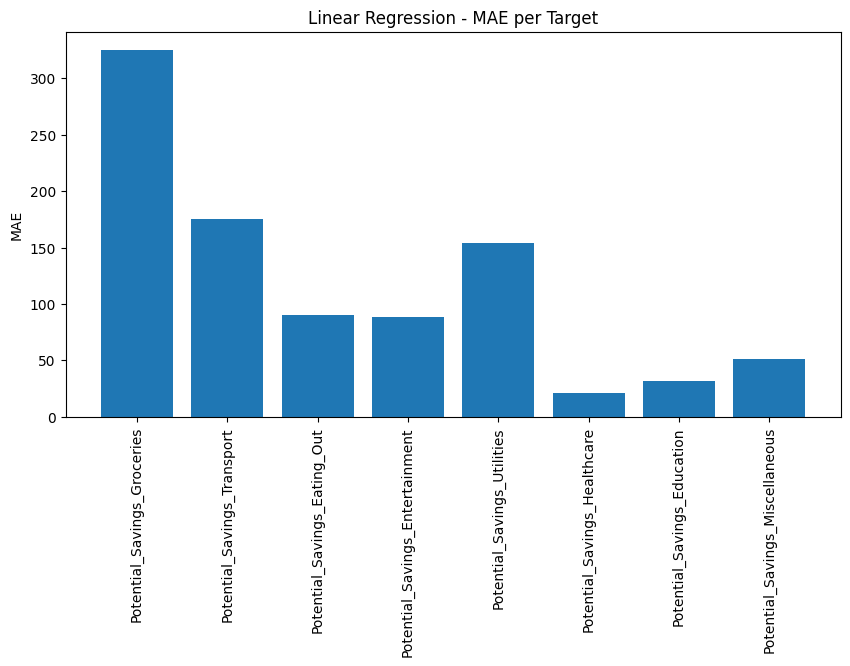

In [ ]:
errors = [
    mean_absolute_error(y_test[col], lr_preds[:, i])
    for i, col in enumerate(targets)
]

plt.figure(figsize=(10,5))
plt.bar(targets, errors)
plt.xticks(rotation=90)
plt.title("Linear Regression - MAE per Target")
plt.ylabel("MAE")
plt.show()


STEP 13 — Save All 3 Models

In [ ]:
pickle.dump(lr, open("/content/drive/MyDrive/Finance tracker project/Suggesting Savings/multi_lr.pkl", "wb"))
pickle.dump(dt, open("/content/drive/MyDrive/Finance tracker project/Suggesting Savings/multi_dt.pkl", "wb"))
pickle.dump(knn, open("/content/drive/MyDrive/Finance tracker project/Suggesting Savings/multi_knn.pkl", "wb"))


Step 1 — Prepare Real-World Input

You need a single row or multiple rows in the same feature format as your X:

In [ ]:
feature_columns = X_train.columns  # save this during training


In [ ]:
# Initialize empty DataFrame with correct columns
real_X = pd.DataFrame(columns=feature_columns)

# Fill in values for the user (others can be 0 or default)
real_X.loc[0] = 0  # start with zeros for all features

# Example: Fill in known features
real_X.loc[0, "Income"] = 50000
real_X.loc[0, "Age"] = 30
real_X.loc[0, "Dependents"] = 2
real_X.loc[0, "Occupationencoded"] = 1
real_X.loc[0, "City_Tierencoded"] = 2
real_X.loc[0, "Disposable_Income"] = 30000
real_X.loc[0, "Desired_Savings"] = 5000
real_X.loc[0, "Savings_Efficiency"] = 0.1
real_X.loc[0, "Spending_Trend"] = 0.5
real_X.loc[0, "Weekly_Income"] = 12500
real_X.loc[0, "Weekly_Overspend_Trend"] = 0.2
real_X.loc[0, "Total_Expenses"] = 25000
real_X.loc[0, "Actual_Savings"] = 5000

# Fill weekly category spends
real_X.loc[0, "Rent_W1"] = 10000
real_X.loc[0, "Rent_W2"] = 10000
real_X.loc[0, "Rent_W3"] = 10000
real_X.loc[0, "Rent_W4"] = 10000
# Repeat for Groceries_W1..W4, Eating_Out_W1..W4, etc.


/tmp/ipython-input-4267809041.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  real_X.loc[0, "Savings_Efficiency"] = 0.1
/tmp/ipython-input-4267809041.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  real_X.loc[0, "Spending_Trend"] = 0.5
/tmp/ipython-input-4267809041.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  real_X.loc[0, "Weekly_Overspend_Trend"] = 0.2


Step 2 — Convert to Numeric (safety)

In [ ]:
real_X = real_X[feature_columns]


In [ ]:
real_X = real_X.astype(float)


Step 3 — Load Your Saved Model

In [ ]:
import pickle

lr_model = pickle.load(open("/content/drive/MyDrive/Finance tracker project/Suggesting Savings/multi_lr.pkl", "rb"))  # example using Linear Regression


Step 4 — Predict Multi-Output Savings

In [ ]:
predicted_savings = lr_model.predict(real_X)


Step 5 — Map Predictions to Target Columns

In [ ]:
pred_df = pd.DataFrame(predicted_savings, columns=targets)
# pred_df = pred_df.clip(lower=0)
print(pred_df)


   Potential_Savings_Groceries  Potential_Savings_Transport  \
0                  -658.580656                   -31.376187   

   Potential_Savings_Eating_Out  Potential_Savings_Entertainment  \
0                   -305.344635                      -219.740826   

   Potential_Savings_Utilities  Potential_Savings_Healthcare  \
0                   115.953646                    -26.756052   

   Potential_Savings_Education  Potential_Savings_Miscellaneous  
0                   -51.605384                      -327.467812  
